In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import optuna
import tensorflow as tf
from statsmodels.graphics.tsaplots import plot_ccf
from statsmodels.tsa.stattools import grangercausalitytests


import warnings

c:\Users\Marwa\anaconda3\envs\cc_abs\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## NOTE:
- Our data is quarterly, thus neural networks do not preform decently with such lack of data (~140 data points). 
- Aligning with our end goal of practice + showcasing our work, we will interpolate more data
- In real world cases, where a credit card company has its own data, interpolation (most likely!) wont be necessary



features that we will use:
- 'charge_off',      # target's own history
- 'delinquency',     # strongest credit predictor
- 'sp500_return',    # macro leading indicator
- 'anomaly_flag'     # structural breaks


While this wont fix the amount of data problem, we will attempt to use a shallow model to bypass that. 


Load up data

In [3]:
def fix_df(df):

    a=df.groupby(df['date'])['value'].mean().round(2)
    
    b = pd.to_datetime(df['date'].unique())

    df = pd.DataFrame({
        'date':b,
        'value':a.values
    })

    df = df.set_index('date')

    return df

def featureng(df):
    df_fe = df.copy()
    anamoly_flag = ((df_fe['value'] > 5) | 
                          (df_fe['value'] < 2.0)).astype(int)
    
    return anamoly_flag

In [4]:
import yfinance as yf

#S&P
sp500 = yf.download('^GSPC', start ='1985-01-01', end='2025-10-01')
sp500_monthly = sp500['Close'].resample('MS').last()
sp500_monthly = sp500_monthly.pct_change().dropna()
sp500_monthly.name = 'sp500_return'


# Charge off
charge_off = pd.read_csv('../data/CORCCACBS.csv')

charge_off = fix_df(charge_off).dropna()

#Delinquency
delinquency = pd.read_csv('../data/DRCCLACBS.csv')
delinquency = fix_df(delinquency)
delinquency_lag = delinquency.shift(1).dropna() #we shift by one since this would be data leakage. Leaking future information

#Have to fix up anamoly flag + delinquency + merge them, THen check correlation, etc.

[*********************100%***********************]  1 of 1 completed


Interpolating Charge-Off Rates:

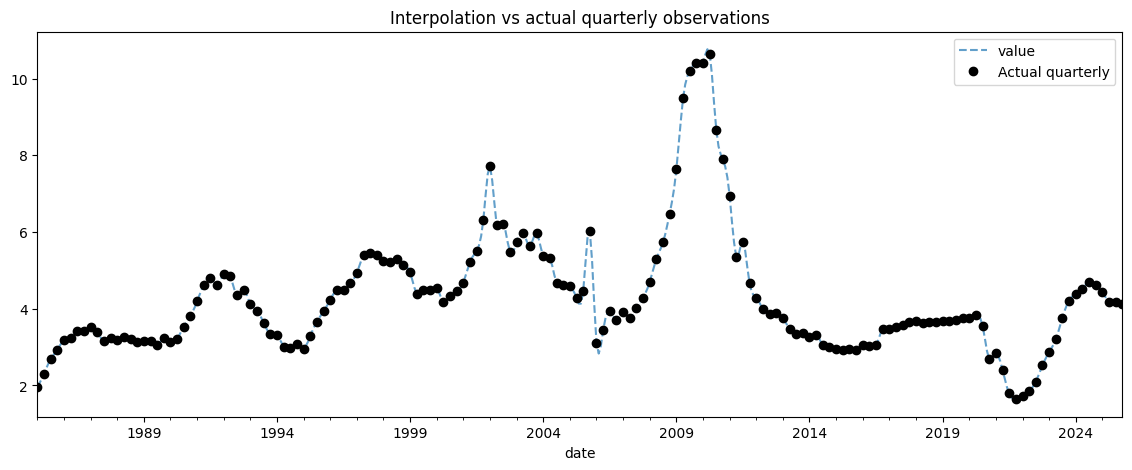

In [5]:
charge_off_monthly = charge_off.resample('MS').mean()

#Cubic spline interpolation
co_monthly_spline = charge_off_monthly.interpolate(method='cubicspline').dropna()


fig, ax = plt.subplots(figsize=(14, 5))
co_monthly_spline.plot(ax=ax, label='Cubic spline', linestyle='--', alpha=0.7)
charge_off['value'].plot(ax=ax, label='Actual quarterly', marker='o', 
                 linewidth=0, markersize=6, color='black')
ax.legend()
plt.title('Interpolation vs actual quarterly observations')
plt.show()

Interpolating Delinquency rates

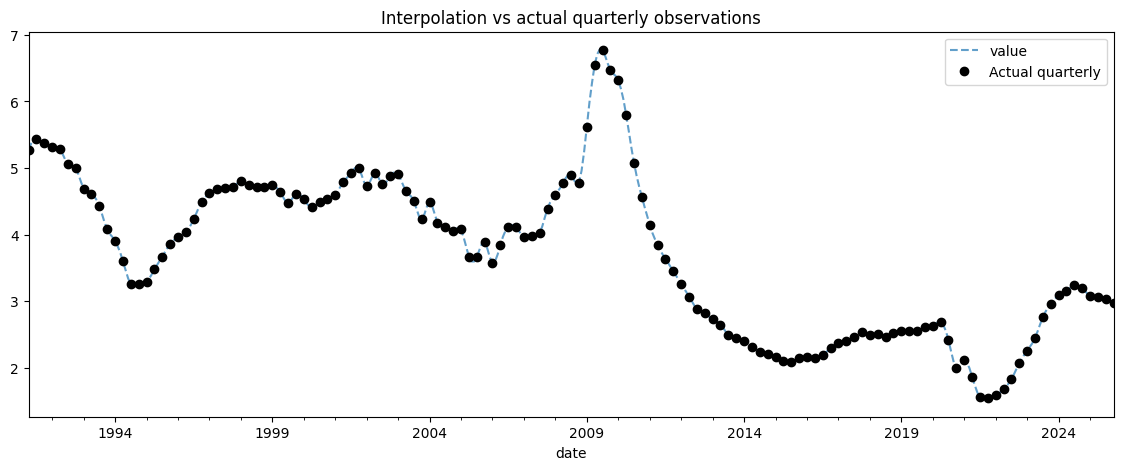

In [6]:
delinquency_lag = delinquency_lag.resample('MS').mean()

#Cubic spline interpolation
delinquency_monthly_spline = delinquency_lag.interpolate(method='cubicspline').dropna()


fig, ax = plt.subplots(figsize=(14, 5))
delinquency_monthly_spline.plot(ax=ax, label='Cubic spline', linestyle='--', alpha=0.7)
delinquency_lag['value'].plot(ax=ax, label='Actual quarterly', marker='o', 
                 linewidth=0, markersize=6, color='black')
ax.legend()
plt.title('Interpolation vs actual quarterly observations')
plt.show()

In [7]:
#Anamoly flag after interpolating charge-off data
charge_off_anamolyflag = featureng(co_monthly_spline).dropna()

In [8]:
"""data = co_monthly_spline, sp500_monthly, delinquency_monthly_spline, charge_off_anamolyflag
for _ in data:
    print('\n', _.columns)"""

co_monthly_spline = co_monthly_spline.rename(columns={'value':'charge_off'})
sp500_monthly = sp500_monthly.rename(columns={'^GSPC':'sp500_return'})
delinquency_monthly_spline = delinquency_monthly_spline.rename(columns={'value':'delinquency_rate'})
charge_off_anamolyflag.name = 'anamoly_flag'

In [9]:
df_combined = pd.concat([co_monthly_spline, sp500_monthly, delinquency_monthly_spline, charge_off_anamolyflag], axis=1).dropna()


print(df_combined.shape)
print(df_combined.head())



(414, 4)
            charge_off  sp500_return  delinquency_rate  anamoly_flag
1991-04-01    4.630000      0.000320          5.270000             0
1991-05-01    4.740036      0.038605          5.369293             0
1991-06-01    4.807280     -0.047893          5.423769             0
1991-07-01    4.810000      0.044859          5.440000             0
1991-08-01    4.744493      0.019649          5.429606             0


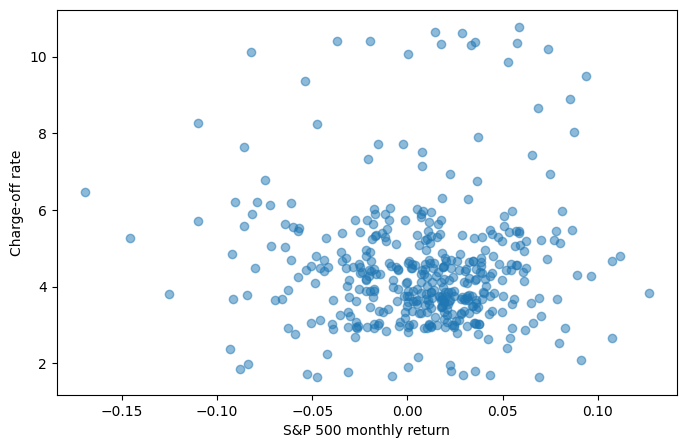

                  charge_off  sp500_return  delinquency_rate  anamoly_flag
charge_off          1.000000     -0.009992          0.803223      0.611032
sp500_return       -0.009992      1.000000         -0.032503     -0.086970
delinquency_rate    0.803223     -0.032503          1.000000      0.446347
anamoly_flag        0.611032     -0.086970          0.446347      1.000000


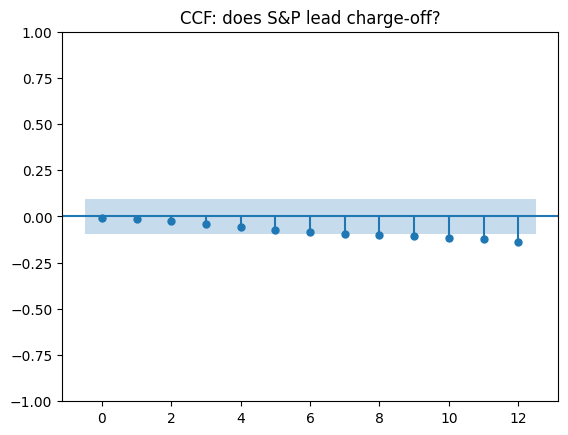


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=1.2160  , p=0.2708  , df_denom=410, df_num=1
ssr based chi2 test:   chi2=1.2249  , p=0.2684  , df=1
likelihood ratio test: chi2=1.2230  , p=0.2688  , df=1
parameter F test:         F=1.2160  , p=0.2708  , df_denom=410, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=1.4674  , p=0.2317  , df_denom=407, df_num=2
ssr based chi2 test:   chi2=2.9708  , p=0.2264  , df=2
likelihood ratio test: chi2=2.9601  , p=0.2276  , df=2
parameter F test:         F=1.4674  , p=0.2317  , df_denom=407, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=5.4926  , p=0.0010  , df_denom=404, df_num=3
ssr based chi2 test:   chi2=16.7633 , p=0.0008  , df=3
likelihood ratio test: chi2=16.4305 , p=0.0009  , df=3
parameter F test:         F=5.4926  , p=0.0010  , df_denom=404, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=4.3080  , p=0.0020  

{np.int64(1): ({'ssr_ftest': (np.float64(1.2159561499514104),
    np.float64(0.2708025589487537),
    np.float64(410.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(1.224853390073006),
    np.float64(0.26841027098124),
    np.int64(1)),
   'lrtest': (np.float64(1.2230406707785733),
    np.float64(0.26876474357238817),
    np.int64(1)),
   'params_ftest': (np.float64(1.215956149951251),
    np.float64(0.27080255894878524),
    np.float64(410.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(1.4673619421490616),
    np.float64(0.23174979969831508),
    np.float64(407.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(2.970777003269845),
    np.float64(0.22641436123798667),
    np.int64(2)),
   'lrtest': (np.float64(2.960117635385359),
    np.float64(0.22762429965396608),
    np.int64(2)),
   'params_ftest': (np.float64(1.4673619421489426),
    np.float64(0.23174979969834242),
    np.float64(407.0),
    2.0)},
   array([[0., 0., 1., 0., 0.],
      

In [ ]:
# Scatter plot
fig, ax = plt.subplots(figsize=(8,5))
ax.scatter(df_combined['sp500_return'], 
           df_combined['charge_off'], alpha=0.5)
ax.set_xlabel('S&P 500 monthly return')
ax.set_ylabel('Charge-off rate')
plt.show()

# Correlation
print(df_combined.corr())

# 3. CCF, checking if S&P lead charge-off
plot_ccf(df_combined['charge_off'], 
         df_combined['sp500_return'], 
         lags=12)
plt.title('CCF: does S&P lead charge-off?')
plt.show()


#
grangercausalitytests(
    df_combined[['charge_off', 'sp500_return']].dropna(), 
    maxlag=6
)


### Explaining plots and results from above:

- Looking at the linear relationship between S&P and Charge off: -0.009, so practically no LINEAR relationship.

- - Versus Delinquency and Charge off: (0.803) very strong
- - Anamoly Flag and Charge off: 0.611, again strong.


## CCF Plot

- Again lags are sitting really close to zero and within the confidence interval (highlited region) which again tells us the lack of linearily relationship with lag between the S&P and charge off


## Granger Causality

- Short explanation of its use: used to determine if one time series is useful in forecasting another.
- Lags 1 & 2 both with p value > 0.05
- Lags 3 to 6: all having a p value < 0.05

- This tells us that the S&P doesn't predict charge-off next month but the S&P 3-6 months ago does!


- I'll create new features using lagged S&P

In [11]:
df_combined['sp500_lag3'] = df_combined['sp500_return'].shift(3)
df_combined['sp500_lag4'] = df_combined['sp500_return'].shift(4)
df_combined['sp500_lag5'] = df_combined['sp500_return'].shift(5)
df_combined['sp500_lag6'] = df_combined['sp500_return'].shift(6)

In [12]:
print(df_combined.columns)

Index(['charge_off', 'sp500_return', 'delinquency_rate', 'anamoly_flag',
       'sp500_lag3', 'sp500_lag4', 'sp500_lag5', 'sp500_lag6'],
      dtype='str')


In [ ]:
def traintestsplit(df):
    train = df.loc[:'2015']
    val = df.loc['2016':'2019']
    test = df.loc['2020':]

    return train,val ,test

train_set, val_set, test_set = traintestsplit(df_monthly_spline)


Creating our timeseries data set via Tensorflow

GradDescent requires IID, shuffling training windows (not the contents)
- so the model's weight doesn't update / get biased toward whatever pattern is most recent!

In [ ]:
seq_length = 8

train_dataset = tf.keras.utils.timeseries_dataset_from_array(
    train_set,targets = train_set[seq_length:],#targets are 3 steps into the future
    sequence_length=seq_length, batch_size=4,shuffle = True, seed=11
    )

val_dataset = tf.keras.utils.timeseries_dataset_from_array(
    val_set, targets=val_set[seq_length:], sequence_length=seq_length, batch_size=4, shuffle= True, seed=11
)

test_dataset = tf.keras.utils.timeseries_dataset_from_array(
    test_set, targets=test_set[seq_length:], sequence_length=seq_length, batch_size=4,shuffle= True, seed=11
)

Trying a basic linear model first: Using Huber Loss

In [ ]:
tf.random.set_seed(11)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(1,input_shape=[seq_length])
])

early_stopping_cb = tf.keras.callbacks.EarlyStopping(monitor='val_mae',
                                                     patience=50,
                                                     restore_best_weights=True)

opt = tf.keras.optimizers.SGD(learning_rate=.02,momentum=0.9)


model.compile(loss=tf.keras.losses.Huber(),optimizer=opt,metrics=['mae'])


history = model.fit(train_dataset, validation_data=val_dataset, epochs=500,
                    callbacks=[early_stopping_cb])

In [ ]:
best_val_mae = min(history.history['val_mae'])
best_epoch = history.history['val_mae'].index(best_val_mae) + 1  # +1 since epochs start at 1
print(f"Best epoch: {best_epoch}, Val MAE: {best_val_mae:.4f}")

plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.axvline(x=best_epoch-1, color='red', linestyle='--', label=f'Best epoch ({best_epoch})')
plt.legend()
plt.show()

Using a simple RNN

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(32,input_shape=[None,1]), #Univariate sequence of any length 
    tf.keras.layers.Dense(1) #no activation function by default
])

early_stopping_cb = tf.keras.callbacks.EarlyStopping(monitor='val_mae',
                                                     patience=50,
                                                     restore_best_weights=True)

opt = tf.keras.optimizers.SGD(learning_rate=.02,momentum=0.9)


model.compile(loss=tf.keras.losses.Huber(),optimizer=opt,metrics=['mae'])


history = model.fit(train_dataset, validation_data=val_dataset, epochs=500,
                    callbacks=[early_stopping_cb])

In [ ]:
best_val_mae = min(history.history['val_mae'])
best_epoch = history.history['val_mae'].index(best_val_mae) + 1  # +1 since epochs start at 1
print(f"Best epoch: {best_epoch}, Val MAE: {best_val_mae:.4f}")

plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.axvline(x=best_epoch-1, color='red', linestyle='--', label=f'Best epoch ({best_epoch})')
plt.legend()
plt.show()

## Not enough data

Biggest tell: Our train MAE is higher than our Validation, its also very erratic... we'll have to use simpler models as RNN's will require a much higher volume of data